In [2]:
# ============================================
# PART 0 – Setup
# ============================================
# Install (if needed) and import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Make plots a bit prettier
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
# ============================================
# UPLOAD THE DATASET (THIS FIXES YOUR ERROR)
# ============================================

from google.colab import files
import pandas as pd

uploaded = files.upload()
# <-- This opens the upload dialog

# Automatically load the uploaded CSV
for filename in uploaded.keys():
    df = pd.read_csv(filename)

df.head()


Saving ChurnData.csv to ChurnData.csv


,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [4]:
# Basic info to understand the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tenure    200 non-null    float64
 1   age       200 non-null    float64
 2   address   200 non-null    float64
 3   income    200 non-null    float64
 4   ed        200 non-null    float64
 5   employ    200 non-null    float64
 6   equip     200 non-null    float64
 7   callcard  200 non-null    float64
 8   wireless  200 non-null    float64
 9   longmon   200 non-null    float64
 10  tollmon   200 non-null    float64
 11  equipmon  200 non-null    float64
 12  cardmon   200 non-null    float64
 13  wiremon   200 non-null    float64
 14  longten   200 non-null    float64
 15  tollten   200 non-null    float64
 16  cardten   200 non-null    float64
 17  voice     200 non-null    float64
 18  pager     200 non-null    float64
 19  internet  200 non-null    float64
 20  callwait  200 non-null    float6

In [5]:
# Check for missing values
df.isna().sum()


,0
tenure,0
age,0
address,0
income,0
ed,0
employ,0
equip,0
callcard,0
wireless,0
longmon,0


In [6]:
# ============================================
# PART 2 – Data Visualization for Assumptions
# ============================================

# We will focus on these four predictors and the churn target
features = ["tenure", "age", "income", "ed"]
target = "churn"


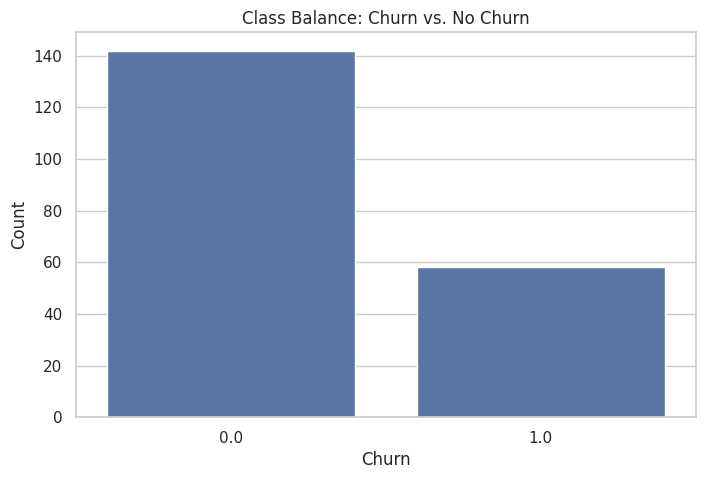

In [7]:
# 1) Distribution of the target variable (class balance)
sns.countplot(x=target, data=df)
plt.title("Class Balance: Churn vs. No Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


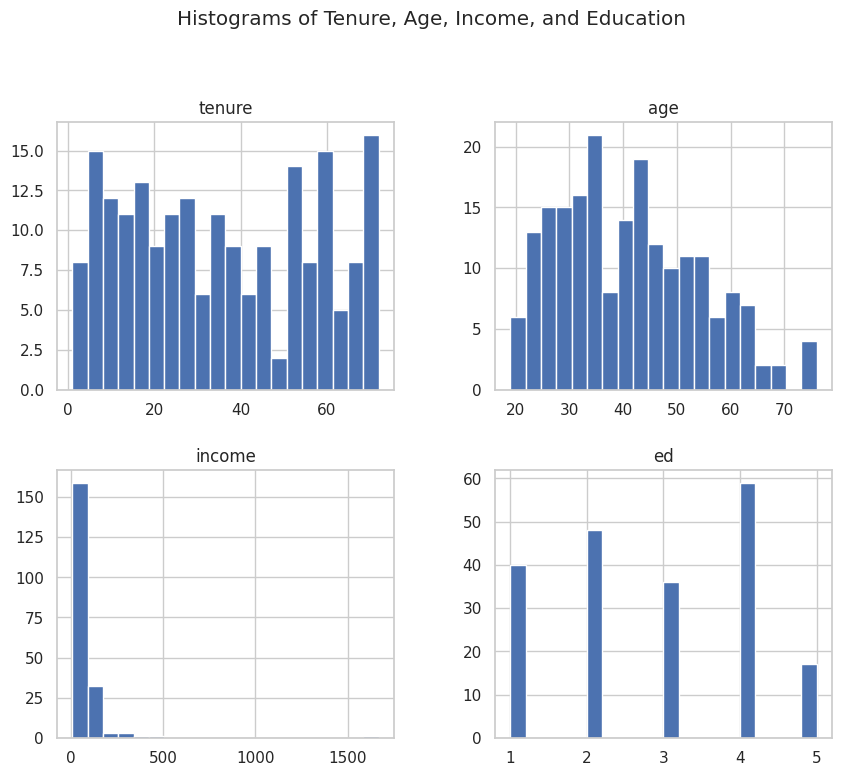

In [8]:
# 2) Histograms for each predictor (overall distribution)
df[features].hist(bins=20, figsize=(10, 8))
plt.suptitle("Histograms of Tenure, Age, Income, and Education", y=1.02)
plt.show()


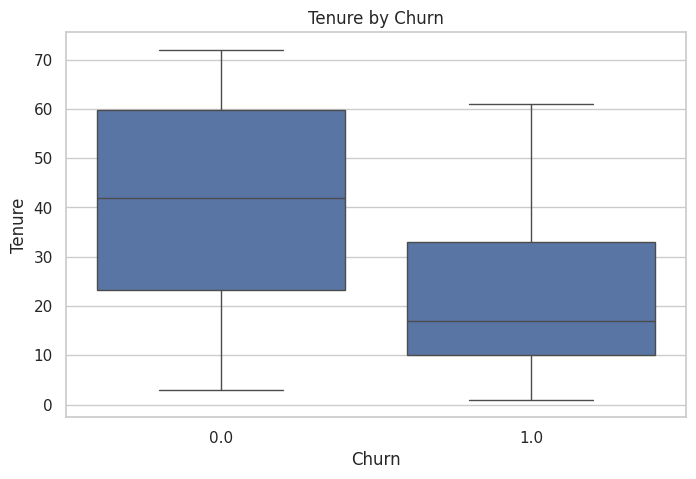

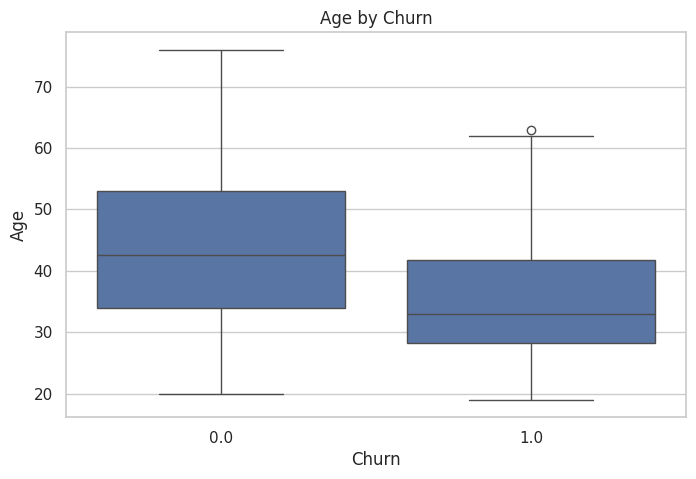

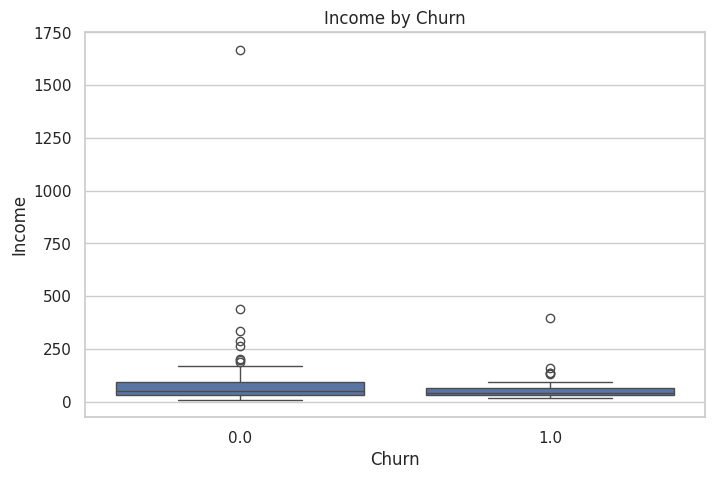

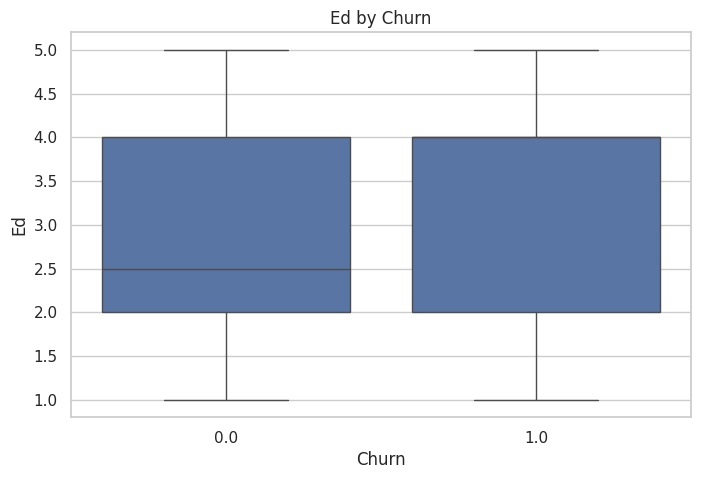

In [9]:
# 3) Boxplots of each predictor grouped by churn
for col in features:
    plt.figure()
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col.capitalize()} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col.capitalize())
    plt.show()


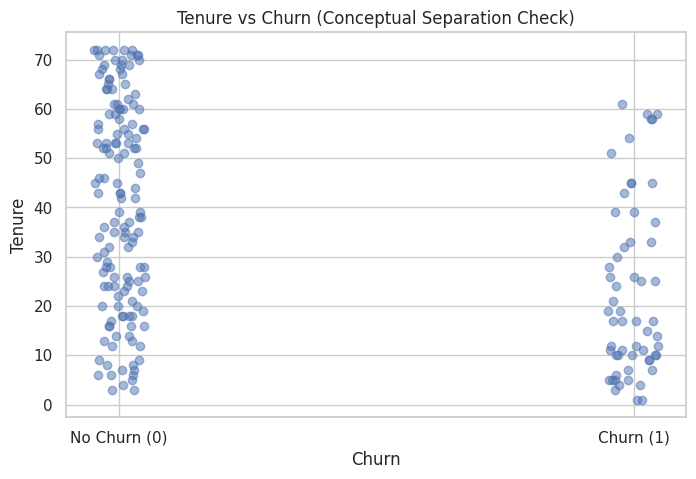

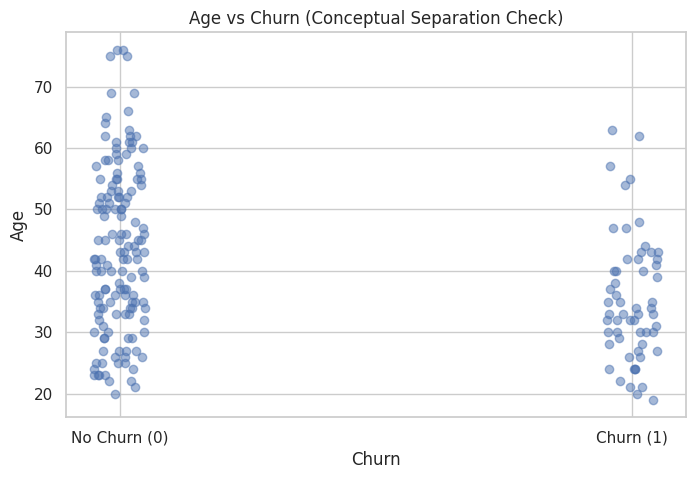

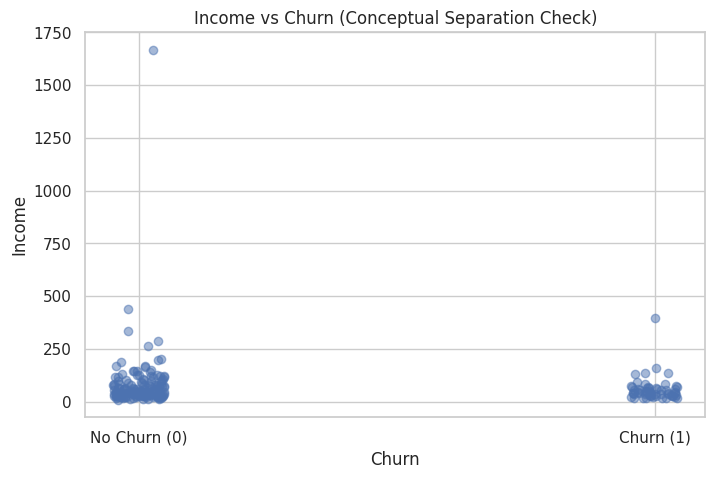

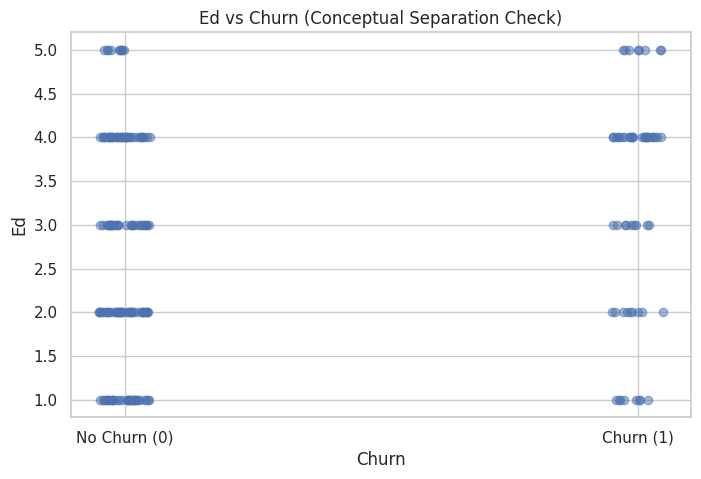


These plots help you conceptually check:
whether the predictors separate churn vs. non-churn reasonably,
whether there are extreme outliers,
and whether predictors are highly correlated with each other.



In [10]:
# 4) Pairwise relationships (scatter-like view) between predictors and churn
# Convert churn to a small jittered value so we can visualize separation
plot_df = df.copy()
plot_df[target] = plot_df[target].astype(int)

for col in features:
    plt.figure()
    # We'll plot churn on the x-axis as 0/1 with jitter, and the predictor on y
    x_jitter = plot_df[target] + (np.random.rand(len(plot_df)) - 0.5) * 0.1
    plt.scatter(x_jitter, plot_df[col], alpha=0.5)
    plt.xticks([0, 1], ["No Churn (0)", "Churn (1)"])
    plt.title(f"{col.capitalize()} vs Churn (Conceptual Separation Check)")
    plt.xlabel("Churn")
    plt.ylabel(col.capitalize())
    plt.show()

print("""
These plots help you conceptually check:
whether the predictors separate churn vs. non-churn reasonably,
whether there are extreme outliers,
and whether predictors are highly correlated with each other.
""")


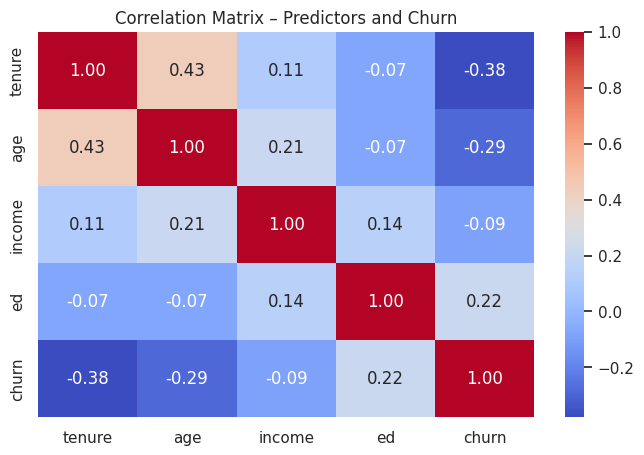

In [11]:
# 5) Correlation matrix for the predictors (to spot very strong relationships)
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix – Predictors and Churn")
plt.show()


In [12]:
# ============================================
# PART 3 – Prepare Data for Logistic Regression
# ============================================
X = df[features]
y = df[target].astype(int)

# make sure target is integer 0/1

# Split into training and test sets
# (e.g., 80% train, 20% test – you can adjust test_size if needed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # helps preserve class balance
)

# Scale AFTER splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit on train only
# transform test using same parameters

# Optional: convert back to DataFrame for clarity (not required)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)
X_train_scaled_df.head()


,tenure,age,income,ed
74,0.406548,-1.067295,-0.403960,-0.657274
117,-1.073911,-1.145306,-0.176227,0.127531
175,0.822927,-0.131157,0.293474,0.127531
44,-0.056096,-0.599226,-0.254510,0.912335
160,-0.611268,0.180889,-0.261627,-0.657274


In [13]:
# ============================================
# PART 4 – Train Logistic Regression Model
# ============================================

log_reg = LogisticRegression(max_iter=1000)  # increase max_iter just in case
log_reg.fit(X_train_scaled, y_train)

# Model coefficients (optional for interpretation)
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": log_reg.coef_[0]
})
coef_table


,feature,coefficient
0,tenure,-0.759927
1,age,-0.392738
2,income,-0.253375
3,ed,0.625443


In [14]:
# Predictions on the test set
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Basic accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.3f}")


Test Accuracy: 0.725


In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[25,  3],
       [ 8,  4]])

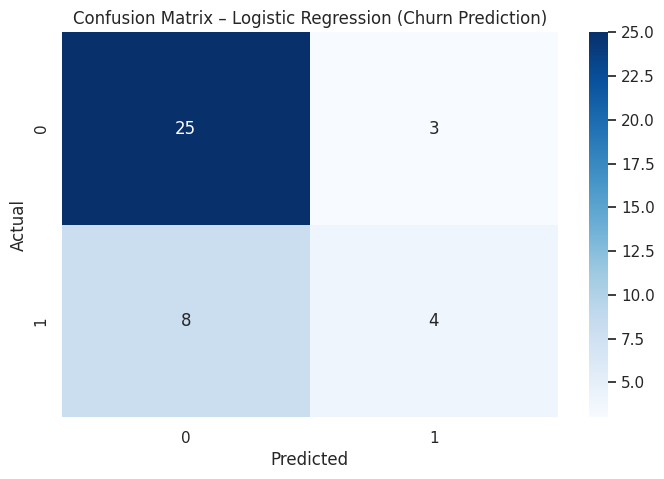

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression (Churn Prediction)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [16]:
# Classification report (precision, recall, f1)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.89      0.82        28
           1       0.57      0.33      0.42        12

    accuracy                           0.72        40
   macro avg       0.66      0.61      0.62        40
weighted avg       0.70      0.72      0.70        40



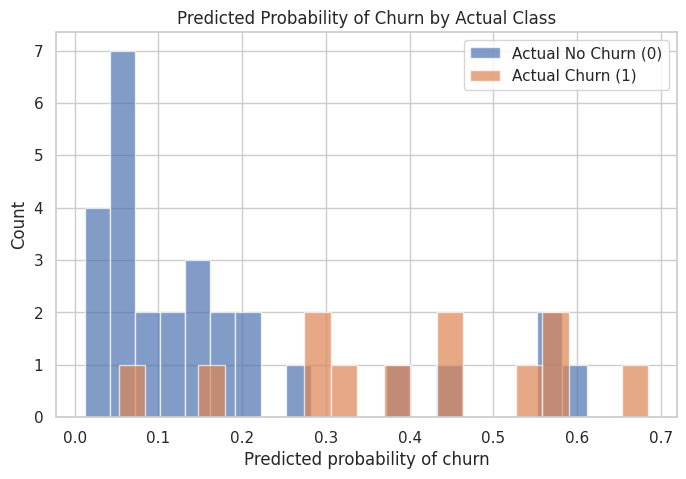

In [17]:
plt.figure()
plt.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.7, label="Actual No Churn (0)")
plt.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.7, label="Actual Churn (1)")
plt.title("Predicted Probability of Churn by Actual Class")
plt.xlabel("Predicted probability of churn")
plt.ylabel("Count")
plt.legend()
plt.show()


In [18]:
print(
    "This logistic regression model learns how tenure, age, income, and education relate to churn. "
    "After scaling the features, it estimates the probability that a customer will churn and classifies churn vs no churn. "
    "The confusion matrix and classification report summarize how well the model performs on unseen test data."
)


This logistic regression model learns how tenure, age, income, and education relate to churn. After scaling the features, it estimates the probability that a customer will churn and classifies churn vs no churn. The confusion matrix and classification report summarize how well the model performs on unseen test data.
